### Politicians and Donors in 2024: A Bipartite Network Analysis

#### Maxfield Raynolds
#### Data 602
#### Project 2
#### Spring 2026

#### Abstract

Who pays for politicians? The interaction between politicians and major donors is one worthy of scrutiny. This project examines a bipartite network of political candidates and their donors. Following money in politics is an incredibly complicated and opaque process. As a result, the scope of this project was limited.

The network was constructed from data downloaded using OpenFEC's API. The network consisted of nodes of politicians and donors during the 2024 election. The politicians were limited to federal incumbents in the House, Senate, and Presidency. Donors were limited to the top ten donors by amount to the registered principal campaign committee for the federal incumbent. Ostensibly, there was the potential for this to be a tripartitie network with nodes for the committees but limiting the donation examinations to the principal campaign committees limited what candidate the funds would go to.

The analysis of the data included building the network and analyzing summary statistics. Then an island method was used to reduce the overall network size to identify donor that were most connected and the candidates they were connected to. Then projections of both types of nodes were created and centrality measures were calculated for each and compared. Finally, an analysis was performed to identify communities and cliques within each network projections.

The following code loads the necessary packages.

In [814]:
# Import packages

from os import getcwd
from dotenv import load_dotenv

import requests
import networkx as nx
import pandas as pd
import time
import os
import numpy as np
import time
from networkx.algorithms import bipartite as bi

### Data Acquisition

The data was acquired through API call to the OpenFEC website. This first API call collects a list of 2024 incumbent candidates and their unique candidate number.

In [815]:
from dotenv import load_dotenv
import os
import requests
import time

load_dotenv()
api_key = os.getenv('FEC_API_KEY')

if os.path.exists('all_incumbents.csv'):
    print('Loading committee ids from file...')
    all_results = pd.read_csv('all_incumbents.csv')

else:
        print("Calling API for candidates...")
        page = 1
        url = 'https://api.open.fec.gov/v1/candidates/'
        all_results = []

        max_retries = 5
        retries = 0

        while True:

            params = {
                "api_key": api_key,
                "per_page": 100,
                "page": page,
                "election_year": 2024,
                "incumbent_challenge": "I",
                "candidate_inactive": False
            }

            try:
                r = requests.get(url, params=params, timeout=30)

                if r.status_code in [429, 502, 504]:
                    print(f"Error {r.status_code}, waiting 5 seconds...")
                    time.sleep(5)
                    continue

                r.raise_for_status()

                data = r.json()
                retries = 0  # reset on success

            except requests.exceptions.RequestException as e:
                retries += 1
                print(f"Connection error: {e}")

                if retries >= max_retries:
                    print("Max retries reached, stopping...")
                    break

                time.sleep(5)
                continue

            results = data['results']

            if not results:
                break

            all_results.extend(results)

            pages = data['pagination']['pages']

            if page >= pages:
                break

            page += 1

        print(len(all_results))
cand_ids_nos = pd.DataFrame(all_results)
cand_ids_nos = cand_ids_nos[cand_ids_nos['candidate_inactive'] == False]
cand_ids_nos.to_csv('data/cand_id_nos.csv')

Loading committee ids from file...


The data on incumbents was saved.

In [816]:
all_results = pd.DataFrame(all_results)
all_results.to_csv('all_incumbents.csv')

Then the candidate numbers were made into a list.

In [817]:
candidate_id = cand_ids_nos['candidate_id'].to_list()

In [818]:
len(candidate_id)

494

In [819]:
candidate_id[:5]

['H4NC12100', 'H6AL04098', 'H2CA31125', 'H2MO04207', 'H2GA12121']

The list of candidate numbers was used in an API call to obtain a list of the principal campaign committee.

In [820]:
file_name = "committees_all.csv"
file_exists = os.path.exists(file_name)

if os.path.exists('committees_all.csv'):
    committees = pd.read_csv('committees_all.csv')

else:
    print("Calling API for committees...")

    for candidate in candidate_id:
        url = f'https://api.open.fec.gov/v1/candidate/{candidate}/committees/'
        page = 1
        committee_results = []
        retries = 0

        while True:
            params = {
                "api_key": api_key,
                "per_page": 100,
                "page": page,
                "cycle": 2024,
                "designation": "P"
            }

            try:
                r = requests.get(url, params=params, timeout=30)

                if r.status_code in [429, 502, 504]:
                    retries += 1
                    if retries >= 5:
                        print(f"Skipping {candidate} after retries")
                        break
                    print(f'Error {r.status_code}, waiting 5 seconds...')
                    time.sleep(5)
                    continue

                r.raise_for_status()
                retries = 0

            except requests.exceptions.RequestException as e:
                print(f'Connection error: {e}')
                break

            data = r.json()
            results = data['results']

            if not results:
                break

            committee_results.extend(results)

            pages = data['pagination']['pages']
            if page >= pages:
                break

            page += 1
            time.sleep(1)

        df_candidate = pd.DataFrame(committee_results)

        if not df_candidate.empty:
            df_candidate.to_csv(
                file_name,
                mode='a',
                header=not file_exists,
                index=False
            )
            file_exists = True

        print(f"Candidate {candidate}: {len(committee_results)} committees saved")

The committee id numbers were then converted to a list.

In [821]:
committee_ids = committees['committee_id'].to_list()

The list of committee ids were then used in an API call to download the donors to that committee in the 2023/2024 election cycle.

In [822]:
load_dotenv()
api_key = os.getenv('FEC_API_KEY')

if os.path.exists('funding.parquet'):
    funds = pd.read_parquet('funding.parquet')

else:
    url = 'https://api.open.fec.gov/v1/schedules/schedule_a/'
    file_name = "funding.csv"
    file_exists = os.path.exists(file_name)

    for committee_id in committee_ids:
        page = 1
        funding_results = []
        retries = 0

        print(f"Fetching contributions for committee {committee_id}...")

        while True:
            params = {
                "api_key": api_key,
                "committee_id": committee_id,
                "per_page": 100,
                "page": page,
                "two_year_transaction_period": 2024,
                "min_amount": 1000
            }

            try:
                r = requests.get(url, params=params, timeout=30)

                if r.status_code in [429, 502, 504]:
                    retries += 1
                    if retries >= 5:
                        print(f"Skipping committee {committee_id} after repeated errors.")
                        break
                    print(f"Error {r.status_code}, retrying in 5s...")
                    time.sleep(5)
                    continue

                r.raise_for_status()
                retries = 0

            except requests.exceptions.RequestException as e:
                retries += 1
                print(f"Connection error: {e}")
                if retries >= 5:
                    print(f"Skipping committee {committee_id} after repeated errors.")
                    break
                time.sleep(5)
                continue

            data = r.json()
            results = data['results']

            if not results:
                break

            funding_results.extend(results)

            pages = data['pagination']['pages']
            if page >= pages or page >= 50:  # limit pages to avoid huge committees
                break

            page += 1
            time.sleep(1)

        # Save all contributions for this committee at once
        if funding_results:
            df_committee = pd.DataFrame(funding_results)
            df_committee.to_csv(
                file_name,
                mode='a',
                header=not file_exists,
                index=False
            )
            file_exists = True
            print(f"Committee {committee_id}: {len(funding_results)} contributions saved.")
        else:
            print(f"Committee {committee_id}: no contributions found.")

In [823]:
funds.to_csv('funding.csv')

In [824]:
funds.head(10)

,amendment_indicator,amendment_indicator_desc,back_reference_schedule_name,back_reference_transaction_id,candidate_first_name,candidate_id,candidate_last_name,candidate_middle_name,candidate_name,candidate_office,...,recipient_committee_org_type,recipient_committee_type,report_type,report_year,schedule_type,schedule_type_full,sub_id,transaction_id,two_year_transaction_period,unused_contbr_id
0,A,ADD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,H,30G,2024,SA,ITEMIZED RECEIPTS,4012220251133296271,7575307,2024,C00342733
1,A,ADD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,H,30G,2024,SA,ITEMIZED RECEIPTS,4012220251133296259,7575311,2024,C00300178
2,A,ADD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,H,30G,2024,SA,ITEMIZED RECEIPTS,4012220251133296253,7575310,2024,C00423871
3,A,ADD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,H,30G,2024,SA,ITEMIZED RECEIPTS,4012220251133296275,7546688,2024,C00405555
4,A,ADD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,H,30G,2024,SA,ITEMIZED RECEIPTS,4012220251133296274,7546687,2024,C00326132
5,A,ADD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,H,30G,2024,SA,ITEMIZED RECEIPTS,4012220251133296272,7522717,2024,C00492314
6,A,ADD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,H,30G,2024,SA,ITEMIZED RECEIPTS,4012220251133296269,7583836,2024,C00000729
7,A,ADD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,H,30G,2024,SA,ITEMIZED RECEIPTS,4012220251133296266,7522724,2024,C00550491
8,A,ADD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,H,30G,2024,SA,ITEMIZED RECEIPTS,4012220251133296258,7523011E,2024,C00401224
9,A,ADD,SA11C,7523011E,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,H,30G,2024,SA,ITEMIZED RECEIPTS,4012220251133296257,7523011,2024,C00004036


The data was then cleaned a little bit.

In [825]:
funds['contributor_zip'] = funds['contributor_zip'].astype(str)
funds['election_type_full'] = funds['election_type_full'].astype(str)
# funds.to_parquet('funding.parquet')

And committee ids were used to create a list.

In [826]:
current_committees = funds['committee_id'].to_list()

During the original API call for donations took a very long time and several committees errored out before retrieving donation data. The list of committees retrieved was compared to the original list and a list of mising committees was created.

In [827]:
missing_committees = set(committee_ids) - set(current_committees)

In [828]:
missing_committees

{'C00411587',
 'C00476564',
 'C00499467',
 'C00652719',
 'C00783480',
 'C00796672',
 'C00806018',
 'C00850420',
 'C00872564'}

The list of missing committees was then used to make an API call to obtain the missing committee data which was appended to the data from the original API call.

In [829]:
load_dotenv()
api_key = os.getenv('FEC_API_KEY')

url = 'https://api.open.fec.gov/v1/schedules/schedule_a/'
file_name = "funding.csv"
file_exists = os.path.exists(file_name)

if os.path.exists('funding_final.parquet'):
    funding_final = pd.read_parquet('funding_final.parquet')

else:
    for committee_id in missing_committees:
        page = 1
        funding_results = []
        retries = 0

        print(f"\nRetrying committee {committee_id}...")

        while True:
            params = {
                "api_key": api_key,
                "committee_id": committee_id,
                "per_page": 50,  # 🔽 smaller page size for stability
                "page": page,
                "two_year_transaction_period": 2024,
                "min_amount": 1000
            }

            try:
                r = requests.get(url, params=params, timeout=30)

                if r.status_code in [429, 502, 504]:
                    retries += 1
                    wait = 5 * retries  # 🔼 exponential-ish backoff
                    print(f"Error {r.status_code}, waiting {wait}s...")
                    time.sleep(wait)

                    if retries >= 7:
                        print(f"Skipping {committee_id} after repeated failures.")
                        break
                    continue

                r.raise_for_status()
                retries = 0

            except requests.exceptions.RequestException as e:
                retries += 1
                wait = 5 * retries
                print(f"Connection error: {e}, waiting {wait}s...")

                if retries >= 7:
                    print(f"Skipping {committee_id} after repeated failures.")
                    break

                time.sleep(wait)
                continue

            data = r.json()
            results = data.get('results', [])

            if not results:
                print(f"No results for {committee_id}")
                break

            funding_results.extend(results)

            pages = data['pagination']['pages']

            print(f"{committee_id} | Page {page}/{pages}")

            # 🔽 more conservative cap for problem cases
            if page >= pages or page >= 30:
                break

            page += 1
            time.sleep(1.5)  # 🔽 slower pacing

        # Save results
        if funding_results:
            df_committee = pd.DataFrame(funding_results)
            df_committee.to_csv(
                file_name,
                mode='a',
                header=not file_exists,
                index=False
            )
            file_exists = True

            print(f"✅ {committee_id}: {len(funding_results)} contributions saved.")
        else:
            print(f"❌ {committee_id}: no data retrieved.")

### Cleaning and data preparation

The final dataframe with all funding data was cleaned slightly...

In [830]:
funding_final['contributor_zip'] = funding_final['contributor_zip'].astype(str)
funding_final['election_type_full'] = funding_final['election_type_full'].astype(str)
# funding_final.to_parquet('funding_final.parquet')

In [831]:
funding_final['contribution_receipt_amount'] = pd.to_numeric(funding_final['contribution_receipt_amount'], errors='coerce')
df_funds = funding_final.dropna(subset=['contributor_name', 'committee_id', 'contribution_receipt_amount'])

...and was then aggregated and ranked, to leave data for only the top ten donors per committee.

In [832]:
agg = (
    df_funds
    .groupby(['committee_id', 'contributor_name'], as_index=False)
    ['contribution_receipt_amount']
    .sum()
)

In [833]:
agg['rank'] = agg.groupby('committee_id')['contribution_receipt_amount'] \
    .rank(method='first', ascending=False)

In [834]:
top10 = agg[agg['rank'] <= 10]

top10 = top10.sort_values(['committee_id', 'rank'])
top10['contributor_name'] = df['contributor_name'].replace('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLITICAL ACTION COMMITTEE', 'AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC')

In [835]:
top10.head(20)

,committee_id,contributor_name,contribution_receipt_amount,rank
75,C00096412,NaN,27000.00,1.0
2,C00096412,LABORERS' INTERNATIONAL UNION OF NORTH AMERICA...,21000.00,2.0
65,C00096412,FINSTAD VICTORY COMMITTEE,19500.00,3.0
1,C00096412,AMERICA'S CREDIT UNIONS PAC OF CREDIT UNION NA...,15000.00,4.0
3,C00096412,NATIONAL ELEVATOR CONSTRUCTORS PAC,15000.00,5.0
6,C00096412,AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC,15000.00,6.0
7,C00096412,GREATER TOMORROW PAC,15000.00,7.0
13,C00096412,NATIONAL AUTOMOBILE DEALERS ASSOCIATION PAC,15000.00,8.0
21,C00096412,WINRED,15000.00,9.0
30,C00096412,"SOLIVAN, PEDRO",15000.00,10.0


The candidate data was subset and cleaned slightly so that it could be joined with the committee data.

In [836]:
candidates_subset = all_results[['candidate_id','district','name','office','party','state']]
committees_subset = committees[['candidate_ids','committee_id']]

In [837]:
committees_subset['candidate_ids'] = committees_subset['candidate_ids'].str.replace(r'[^A-Za-z0-9,]','', regex=True)
split_cols = committees_subset['candidate_ids'] \
    .str.strip("[]'") \
    .str.split(",", expand=True)


In [838]:
split_cols.columns = [f'candidate_id{i+1}' for i in range(split_cols.shape[1])]

committees_subset = pd.concat([committees_subset, split_cols], axis=1)

In [839]:
committees_subset = pd.melt(committees_subset, id_vars=['committee_id'], value_vars=['candidate_id1', 'candidate_id2', 'candidate_id3', 'candidate_id4'])

In [840]:
committees_subset = committees_subset.dropna(axis=0, subset=['value'])
committees_subset.drop(columns=['variable'], inplace=True)
committees_subset.rename(columns={'value': 'candidate_id'}, inplace=True)

In [841]:
committees_subset

,committee_id,candidate_id
0,C00546358,H4NC12100
1,C00313247,H6AL04098
2,C00510461,H2CA31125
3,C00792598,H2MO04207
4,C00504019,H2GA12121
...,...,...
1275,C00508804,S8AZ00197
1922,C00783480,H2NC07146
1932,C00783480,H2NC07146
2595,C00783480,H2OR06066


In [842]:
committees_subset = committees_subset.merge(candidates_subset, on = 'candidate_id')

In [843]:
committees_subset.drop_duplicates(inplace = True)

In [844]:
top10

,committee_id,contributor_name,contribution_receipt_amount,rank
75,C00096412,NaN,27000.0,1.0
2,C00096412,LABORERS' INTERNATIONAL UNION OF NORTH AMERICA...,21000.0,2.0
65,C00096412,FINSTAD VICTORY COMMITTEE,19500.0,3.0
1,C00096412,AMERICA'S CREDIT UNIONS PAC OF CREDIT UNION NA...,15000.0,4.0
3,C00096412,NATIONAL ELEVATOR CONSTRUCTORS PAC,15000.0,5.0
...,...,...,...,...
34933,C00887547,NaN,20000.0,6.0
34936,C00887547,NaN,20000.0,7.0
34955,C00887547,NaN,20000.0,8.0
34965,C00887547,NaN,20000.0,9.0


The paired candidate and committee data was then merged with the top10 donor data resulting in a dataframe with information about the top ten donors for each incumbent candidate in during the 2024 election cycle.

In [845]:
df = top10.merge(committees_subset, on = 'committee_id', how = 'left')

In [846]:
df

,committee_id,contributor_name,contribution_receipt_amount,rank,candidate_id,district,name,office,party,state
0,C00096412,NaN,27000.0,1.0,H8NJ04014,4,"SMITH, CHRISTOPHER H",H,REP,NJ
1,C00096412,LABORERS' INTERNATIONAL UNION OF NORTH AMERICA...,21000.0,2.0,H8NJ04014,4,"SMITH, CHRISTOPHER H",H,REP,NJ
2,C00096412,FINSTAD VICTORY COMMITTEE,19500.0,3.0,H8NJ04014,4,"SMITH, CHRISTOPHER H",H,REP,NJ
3,C00096412,AMERICA'S CREDIT UNIONS PAC OF CREDIT UNION NA...,15000.0,4.0,H8NJ04014,4,"SMITH, CHRISTOPHER H",H,REP,NJ
4,C00096412,NATIONAL ELEVATOR CONSTRUCTORS PAC,15000.0,5.0,H8NJ04014,4,"SMITH, CHRISTOPHER H",H,REP,NJ
...,...,...,...,...,...,...,...,...,...,...
4616,C00887547,NaN,20000.0,6.0,H4NJ09194,9,"POU, NELIDA",H,DEM,NJ
4617,C00887547,NaN,20000.0,7.0,H4NJ09194,9,"POU, NELIDA",H,DEM,NJ
4618,C00887547,NaN,20000.0,8.0,H4NJ09194,9,"POU, NELIDA",H,DEM,NJ
4619,C00887547,NaN,20000.0,9.0,H4NJ09194,9,"POU, NELIDA",H,DEM,NJ


The names were cleaned slightly ot be more visually appealling and consistent.

In [847]:
names = df['name'] \
    .str.title() \
    .str.split(",", expand=True) \
    .drop(columns = 2) \
    .rename(columns = {0:'last_name', 1:'first_name'})

names['full_name'] = names['first_name'] + " " + names['last_name']

In [848]:
df = pd.concat([df, names], axis=1)

Then a dataframe was made for the edges of the bipartite network with the contributor name, the candidates name, and the amount they donated.

In [849]:
edges = df[['contributor_name', 'full_name', 'contribution_receipt_amount']]

The following code aggregates donations. In the event that a donator gave multiple times, this code combined those donations into a single edge, rather than having multiple edges between the same nodes. While there may be a time series analysis possible for when multiple donations were made from a donor to a candidate, that is outside the scope of this analysis and the aggregated donation amount is more useful overall. Additionally, to total donated to multiple candidates is an interesting attribute of the node.

In [850]:
donator_aggregator = df[['contributor_name', 'contribution_receipt_amount']] \
    .groupby(by='contributor_name').sum() \
    .reset_index() \
    .sort_values('contribution_receipt_amount', ascending=False) \
    .rename(columns={'contributor_name':'name'})

donator_aggregator['node_type'] = 'donor'

The candidates were then organized and cleaned.

In [851]:
df

,committee_id,contributor_name,contribution_receipt_amount,rank,candidate_id,district,name,office,party,state,last_name,first_name,full_name
0,C00096412,NaN,27000.0,1.0,H8NJ04014,4,"SMITH, CHRISTOPHER H",H,REP,NJ,Smith,Christopher H,Christopher H Smith
1,C00096412,LABORERS' INTERNATIONAL UNION OF NORTH AMERICA...,21000.0,2.0,H8NJ04014,4,"SMITH, CHRISTOPHER H",H,REP,NJ,Smith,Christopher H,Christopher H Smith
2,C00096412,FINSTAD VICTORY COMMITTEE,19500.0,3.0,H8NJ04014,4,"SMITH, CHRISTOPHER H",H,REP,NJ,Smith,Christopher H,Christopher H Smith
3,C00096412,AMERICA'S CREDIT UNIONS PAC OF CREDIT UNION NA...,15000.0,4.0,H8NJ04014,4,"SMITH, CHRISTOPHER H",H,REP,NJ,Smith,Christopher H,Christopher H Smith
4,C00096412,NATIONAL ELEVATOR CONSTRUCTORS PAC,15000.0,5.0,H8NJ04014,4,"SMITH, CHRISTOPHER H",H,REP,NJ,Smith,Christopher H,Christopher H Smith
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4616,C00887547,NaN,20000.0,6.0,H4NJ09194,9,"POU, NELIDA",H,DEM,NJ,Pou,Nelida,Nelida Pou
4617,C00887547,NaN,20000.0,7.0,H4NJ09194,9,"POU, NELIDA",H,DEM,NJ,Pou,Nelida,Nelida Pou
4618,C00887547,NaN,20000.0,8.0,H4NJ09194,9,"POU, NELIDA",H,DEM,NJ,Pou,Nelida,Nelida Pou
4619,C00887547,NaN,20000.0,9.0,H4NJ09194,9,"POU, NELIDA",H,DEM,NJ,Pou,Nelida,Nelida Pou


In [852]:
df = df.loc[:,~df.columns.duplicated()]
edges = edges.loc[:,~edges.columns.duplicated()]
edges['full_name'] = edges['full_name'].str.strip()
edges.rename(columns={'contributor_name':'donor','full_name':'candidate','contribution_receipt_amount':'weight'}, inplace=True )

Then a list of candidates was created with their attributes.

In [853]:
candidates = df[['full_name', 'office','party','state','district','contribution_receipt_amount']] \
    .rename(columns={'full_name':'name'}) \
    .groupby(by=['name','office','party','state','district']).sum() \
    .reset_index()

candidates['node_type'] = 'candidate'
candidates.rename(columns={'contribution_receipt_amount':'donation'}, inplace=True)

In [854]:
donator_aggregator.rename(columns={'contribution_receipt_amount':'donation'}, inplace=True)

In [855]:
donator_aggregator.sort_values('donation', ascending=False, inplace=True)
donator_aggregator

,name,donation,node_type
4,LABORERS' INTERNATIONAL UNION OF NORTH AMERICA...,21000.0,donor
2,FINSTAD VICTORY COMMITTEE,19500.0,donor
0,AMERICA'S CREDIT UNIONS PAC OF CREDIT UNION NA...,15000.0,donor
1,AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC,15000.0,donor
3,GREATER TOMORROW PAC,15000.0,donor
5,NATIONAL AUTOMOBILE DEALERS ASSOCIATION PAC,15000.0,donor
6,NATIONAL ELEVATOR CONSTRUCTORS PAC,15000.0,donor
7,"SOLIVAN, PEDRO",15000.0,donor
8,WINRED,15000.0,donor


The candidate data was then concatenated with the donator data to create a list of nodes for the bipartite network.

In [856]:
nodes = pd.concat([donator_aggregator, candidates], axis=0).reset_index()

In [857]:
nodes.sort_values('donation', inplace=True)

### Constructing the Bipartite Network

The code below constructs the bipartite network and then summarizes several aspects of the network.

In [858]:
B = nx.Graph()
B.add_nodes_from(nodes)
B.add_weighted_edges_from(edge_tuple)
bi.is_bipartite(B)

True

In [859]:
print(f'{len(donor_nodes)} donor nodes')
print(f'{len(candidate_nodes)} candidate nodes')
print(f"${round(donator_aggregator['donation'].sum())} in donations represented in this dataset (this is not all money donated to these candidates, spent by PACs, or spent in other ways during the election).")

2526 donor nodes
462 candidate nodes
$145500 in donations represented in this dataset (this is not all money donated to these candidates, spent by PACs, or spent in other ways during the election).


The code below calculates the total separate subgraphs.

In [860]:
component_subgraphs = [B.subgraph(c).copy() for c in nx.connected_components(B)]
print(len(component_subgraphs))

13


In [861]:
list(nx.isolates(B))
B.remove_nodes_from(list(nx.isolates(B)))

In [862]:
candidate_nodes = {n for n, d in bi.color(B).items() if d == 0}
donor_nodes = set(B) - candidate_nodes

In [863]:
dens = bi.density(B, nodes)
dens

0.0038303537975699835

### Full Network Centrality

The code below calculates centrality metrics for the entire bipartite network as initially constructed.

In [864]:
B_cand_proj = bi.weighted_projected_graph(B, candidate_nodes)
B_donor_proj = bi.weighted_projected_graph(B, donor_nodes)

In [865]:
print(sorted(B_cand_proj.degree(), key = lambda item: (-item[1], item[0]))[:15])
B_d = dict(B_cand_proj.degree())

[('Brendan F Boyle', 291), ('Gregory W. Meeks', 283), ('Brittany Louise Pettersen', 276), ('Kweisi Mfume', 273), ('Emanuel Ii Cleaver', 270), ('Debbie Wasserman Schultz', 261), ('Frederica S. Wilson', 260), ('Mazie K. Hirono', 260), ('Sheila Cherfilus-Mccormick', 260), ('George Latimer', 258), ('Joseph Neguse', 257), ('Wesley Bell', 257), ('April Mcclain Delaney', 255), ('Yvette D Clarke', 255), ('Jared Moskowitz', 254)]


In [866]:
B_dc = nx.degree_centrality(B_cand_proj)
sorted_map(nx.degree_centrality(B_cand_proj))[:15]

[('Brendan F Boyle', 0.631236442516269),
 ('Gregory W. Meeks', 0.613882863340564),
 ('Brittany Louise Pettersen', 0.5986984815618221),
 ('Kweisi Mfume', 0.5921908893709328),
 ('Emanuel Ii Cleaver', 0.5856832971800434),
 ('Debbie Wasserman Schultz', 0.5661605206073753),
 ('Frederica S. Wilson', 0.5639913232104121),
 ('Mazie K. Hirono', 0.5639913232104121),
 ('Sheila Cherfilus-Mccormick', 0.5639913232104121),
 ('George Latimer', 0.559652928416486),
 ('Joseph Neguse', 0.5574837310195228),
 ('Wesley Bell', 0.5574837310195228),
 ('April Mcclain Delaney', 0.5531453362255966),
 ('Yvette D Clarke', 0.5531453362255966),
 ('Jared Moskowitz', 0.5509761388286334)]

In [867]:
B_c = nx.closeness_centrality(B_cand_proj)
sorted_map(nx.closeness_centrality(B_cand_proj))[:15]

[('Brendan F Boyle', 0.7260171589076144),
 ('Gregory W. Meeks', 0.7156946400605868),
 ('Brittany Louise Pettersen', 0.7089745025952292),
 ('Kweisi Mfume', 0.7034700421713531),
 ('Emanuel Ii Cleaver', 0.7002082027176992),
 ('Debbie Wasserman Schultz', 0.6927136195081826),
 ('Frederica S. Wilson', 0.6906016877413894),
 ('Sheila Cherfilus-Mccormick', 0.6906016877413894),
 ('Mazie K. Hirono', 0.6895505436200174),
 ('George Latimer', 0.6874578257334619),
 ('Joseph Neguse', 0.6874578257334619),
 ('Wesley Bell', 0.6864162229671991),
 ('April Mcclain Delaney', 0.684342457943129),
 ('Yvette D Clarke', 0.684342457943129),
 ('Jared Moskowitz', 0.6833102672071666)]

In [868]:
B_b = nx.betweenness_centrality(B_cand_proj)
sorted_map(nx.betweenness_centrality(B_cand_proj))[:15]

[('Gregory W. Meeks', 0.01646363946830888),
 ('Brendan F Boyle', 0.015362024291692157),
 ('Emanuel Ii Cleaver', 0.014241269382399308),
 ('Kweisi Mfume', 0.012867410877068148),
 ('Michael Patrick Guest', 0.007879321383851985),
 ('Rosa L Delauro', 0.007545185763483999),
 ('H Morgan Griffith', 0.0075186923743069565),
 ('Scott Mr. Franklin', 0.007288542924649267),
 ('David Taylor', 0.007245526337280868),
 ('Clay Captain Higgins', 0.006935731640754532),
 ('Henry R. Cuellar', 0.00639549326989963),
 ('Eric Burlison', 0.0061593087188239045),
 ('Thomas Earl Jr. Emmer', 0.0057830393806445595),
 ('Harold Dallas Rogers', 0.005556360056570358),
 ('Michael R Rep. Turner', 0.005499997852167004)]

In [869]:
B_e = nx.eigenvector_centrality(B_cand_proj)
sorted_map(nx.eigenvector_centrality(B_cand_proj))[:15]

[('Brittany Louise Pettersen', 0.07117813926140991),
 ('Sheila Cherfilus-Mccormick', 0.07042575475566411),
 ('Frederica S. Wilson', 0.0703475352934773),
 ('George Latimer', 0.07016536774404812),
 ('Debbie Wasserman Schultz', 0.07015217749433668),
 ('Brendan F Boyle', 0.0701053588552431),
 ('Mazie K. Hirono', 0.07004831653022256),
 ('Wesley Bell', 0.07001436928209559),
 ('Jared Moskowitz', 0.06992507247488572),
 ('Yvette D Clarke', 0.06991179638712246),
 ('April Mcclain Delaney', 0.06988181639781026),
 ('Grace Meng', 0.06969577622086796),
 ('Nikema N. Williams', 0.06969349958851774),
 ('Joseph Neguse', 0.06965420534494698),
 ('Chris Pappas', 0.0696270460759849)]

In [870]:
full_comparison_cand = pd.DataFrame({
    'name': list(B_cand_proj.nodes),
    'degree': [B_d[n] for n in B_cand_proj.nodes()],
    'degree_centrality': [B_dc[n] for n in B_cand_proj.nodes()],
    'closeness_centrality': [B_c[n] for n in B_cand_proj.nodes()],
    'betweenness': [B_b[n] for n in B_cand_proj.nodes()],
    'eigenvector': [B_e[n] for n in B_cand_proj.nodes()]
})

In [871]:
candidates['name'] = candidates['name'].str.strip()
full_comparison_cand['name'] = full_comparison_cand['name'].str.strip()

The dataframe below is the projected candidates from the full bipartite network. Some observations include:

- While the top candidates are generally similarly ranked in degree, closeness, and eigenvector centrality, the betweenness centrality is less consistent. This is likely due to candidates not being between donor committees, it is more likely a donor committee will be between candidates. In many cases candidates are mostly collecting donations from a single or limited number of committees.
- Also interesting is that all the top candidates are from the Democratic party.
- Only one candidate in the top 15 is in the Senate, the rest are in the House.
- Finally, the amount of donations are very different for the most central candidates.

In [872]:
Full_comp_cand = pd.merge(full_comparison_cand, candidates, on='name', how='left')
Full_comp_cand.sort_values('degree', ascending = False)[:15]

,name,degree,degree_centrality,closeness_centrality,betweenness,eigenvector,office,party,state,district,donation,node_type
327,Brendan F Boyle,291,0.631236,0.726017,0.015362,0.070105,H,DEM,PA,2,791847.70,candidate
380,Gregory W. Meeks,283,0.613883,0.715695,0.016464,0.069311,H,DEM,NY,5,2050100.00,candidate
379,Brittany Louise Pettersen,276,0.598698,0.708975,0.005384,0.071178,H,DEM,CO,7,953695.47,candidate
288,Kweisi Mfume,273,0.592191,0.703470,0.012867,0.068828,H,DEM,MD,7,387200.00,candidate
420,Emanuel Ii Cleaver,270,0.585683,0.700208,0.014241,0.068623,H,DEM,MO,5,672100.00,candidate
448,Debbie Wasserman Schultz,261,0.566161,0.692714,0.003121,0.070152,H,DEM,FL,25,1163745.00,candidate
261,Mazie K. Hirono,260,0.563991,0.689551,0.002978,0.070048,S,DEM,HI,0,1915200.00,candidate
458,Frederica S. Wilson,260,0.563991,0.690602,0.002525,0.070348,H,DEM,FL,24,237000.00,candidate
322,Sheila Cherfilus-Mccormick,260,0.563991,0.690602,0.002425,0.070426,H,DEM,FL,20,681568.00,candidate
377,George Latimer,258,0.559653,0.687458,0.002349,0.070165,H,DEM,NY,16,1634000.00,candidate


The code below calulates centrality measures for the all committees from the full network.

In [873]:
print(sorted(B_donor_proj.degree(), key = lambda item: (-item[1], item[0]))[:15])
B_d = dict(B_donor_proj.degree())

[('ACTBLUE', 1166), ('WINRED', 943), ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLITICAL ACTION COMMITTEE', 390), ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC', 380), ('HUCK PAC', 274), ('NATIONAL ASSOCIATION OF REALTORS POLITICAL ACTION COMMITTEE', 250), ('AMERICAN REVIVAL PAC', 247), ("LABORERS' INTERNATIONAL UNION OF NORTH AMERICA (LIUNA) PAC", 236), ('SEIU COPE (SERVICE EMPLOYEES INTERNATIONAL UNION COMMITTEE ON POLITICAL EDUCATION)', 195), ('CARPENTERS LEGISLATIVE IMPROVEMENT COMMITTEE UNITED BROTHERHOOD OF CARPENTERS AND JOINERS', 188), ('NATIONAL AUTOMOBILE DEALERS ASSOCIATION POLITICAL ACTION COMMITTEE', 177), ('NATIONAL AUTOMOBILE DEALERS ASSOCIATION PAC', 176), ('AMERICAN CRYSTAL SUGAR COMPANY POLITICAL ACTION COMMITTEE', 169), ("AMERICA'S CREDIT UNIONS PAC OF CREDIT UNION NATIONAL ASSOCIATION, INC.", 161), ('SCALISE LEADERSHIP FUND 2024', 139)]


In [874]:
B_dc = nx.degree_centrality(B_donor_proj)
sorted_map(nx.degree_centrality(B_donor_proj))[:15]

[('ACTBLUE', 0.4617821782178218),
 ('WINRED', 0.37346534653465346),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLITICAL ACTION COMMITTEE',
  0.15445544554455445),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC', 0.15049504950495052),
 ('HUCK PAC', 0.10851485148514853),
 ('NATIONAL ASSOCIATION OF REALTORS POLITICAL ACTION COMMITTEE',
  0.09900990099009901),
 ('AMERICAN REVIVAL PAC', 0.09782178217821783),
 ("LABORERS' INTERNATIONAL UNION OF NORTH AMERICA (LIUNA) PAC",
  0.09346534653465347),
 ('SEIU COPE (SERVICE EMPLOYEES INTERNATIONAL UNION COMMITTEE ON POLITICAL EDUCATION)',
  0.07722772277227723),
 ('CARPENTERS LEGISLATIVE IMPROVEMENT COMMITTEE UNITED BROTHERHOOD OF CARPENTERS AND JOINERS',
  0.07445544554455447),
 ('NATIONAL AUTOMOBILE DEALERS ASSOCIATION POLITICAL ACTION COMMITTEE',
  0.0700990099009901),
 ('NATIONAL AUTOMOBILE DEALERS ASSOCIATION PAC', 0.06970297029702971),
 ('AMERICAN CRYSTAL SUGAR COMPANY POLITICAL ACTION COMMITTEE',
  0.06693069306930693),
 ("AMERICA'S CREDI

In [875]:
B_c = nx.closeness_centrality(B_donor_proj)
sorted_map(nx.closeness_centrality(B_donor_proj))[:15]

[('ACTBLUE', 0.6015876097413664),
 ('WINRED', 0.5600988090695479),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC', 0.5296586564027247),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLITICAL ACTION COMMITTEE',
  0.5284198205063968),
 ('NATIONAL ASSOCIATION OF REALTORS POLITICAL ACTION COMMITTEE',
  0.5099853100434196),
 ('NATIONAL AUTOMOBILE DEALERS ASSOCIATION PAC', 0.5035781997652653),
 ('AMERICAN CRYSTAL SUGAR COMPANY POLITICAL ACTION COMMITTEE',
  0.5012421169507028),
 ("LABORERS' INTERNATIONAL UNION OF NORTH AMERICA (LIUNA) PAC",
  0.500132504697441),
 ("AMERICA'S CREDIT UNIONS PAC OF CREDIT UNION NATIONAL ASSOCIATION, INC.",
  0.49922828763390603),
 ('NATIONAL AUTOMOBILE DEALERS ASSOCIATION POLITICAL ACTION COMMITTEE',
  0.4983273342373339),
 ('CARPENTERS LEGISLATIVE IMPROVEMENT COMMITTEE UNITED BROTHERHOOD OF CARPENTERS AND JOINERS',
  0.4970316831683168),
 ('BUILD POLITICAL ACTION COMMITTEE OF THE NATIONAL ASSOCIATION OF HOME BUILDERS (BUILDPAC)',
  0.49220804433384513),
 ('NA

In [876]:
B_b = nx.betweenness_centrality(B_donor_proj)
sorted_map(nx.betweenness_centrality(B_donor_proj))[:15]

[('ACTBLUE', 0.3983703078186895),
 ('WINRED', 0.29738020167222634),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC', 0.07980348297990303),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLITICAL ACTION COMMITTEE',
  0.06598519570374546),
 ('AMERICAN REVIVAL PAC', 0.04121365977279082),
 ('NATIONAL ASSOCIATION OF REALTORS POLITICAL ACTION COMMITTEE',
  0.03143532072067746),
 ('HUCK PAC', 0.02959714409617892),
 ('NATIONAL AUTOMOBILE DEALERS ASSOCIATION PAC', 0.026921265671912106),
 ("LABORERS' INTERNATIONAL UNION OF NORTH AMERICA (LIUNA) PAC",
  0.023586604432102354),
 ('AMERICAN CRYSTAL SUGAR COMPANY POLITICAL ACTION COMMITTEE',
  0.021347744380797895),
 ("AMERICA'S CREDIT UNIONS PAC OF CREDIT UNION NATIONAL ASSOCIATION, INC.",
  0.019434431762158755),
 ('CARPENTERS LEGISLATIVE IMPROVEMENT COMMITTEE UNITED BROTHERHOOD OF CARPENTERS AND JOINERS',
  0.018349126465845318),
 ('NATIONAL AUTOMOBILE DEALERS ASSOCIATION POLITICAL ACTION COMMITTEE',
  0.0170658632035744),
 ('NATIONAL ASSOCIATION O

In [877]:
B_e = nx.eigenvector_centrality(B_donor_proj)
sorted_map(nx.eigenvector_centrality(B_donor_proj))[:15]

[('ACTBLUE', 0.39024267505206794),
 ('WINRED', 0.2566908547736652),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLITICAL ACTION COMMITTEE',
  0.19775066402877456),
 ('NATIONAL ASSOCIATION OF REALTORS POLITICAL ACTION COMMITTEE',
  0.15122413175385208),
 ("LABORERS' INTERNATIONAL UNION OF NORTH AMERICA (LIUNA) PAC",
  0.14578856894168649),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC', 0.13770576601023457),
 ('CARPENTERS LEGISLATIVE IMPROVEMENT COMMITTEE UNITED BROTHERHOOD OF CARPENTERS AND JOINERS',
  0.12326398143146612),
 ('HUCK PAC', 0.12042169777157727),
 ('NATIONAL AUTOMOBILE DEALERS ASSOCIATION POLITICAL ACTION COMMITTEE',
  0.11872598244646343),
 ('SEIU COPE (SERVICE EMPLOYEES INTERNATIONAL UNION COMMITTEE ON POLITICAL EDUCATION)',
  0.11098127509317746),
 ("AMERICA'S CREDIT UNIONS PAC OF CREDIT UNION NATIONAL ASSOCIATION, INC.",
  0.10746891761856502),
 ('AMERICAN CRYSTAL SUGAR COMPANY POLITICAL ACTION COMMITTEE',
  0.10707796015110671),
 ('AMERICAN DENTAL ASSOCIATION POLIT

In [878]:
full_comparison_donor = pd.DataFrame({
    'name': list(B_donor_proj.nodes),
    'degree': [B_d[n] for n in B_donor_proj.nodes()],
    'degree_centrality': [B_dc[n] for n in B_donor_proj.nodes()],
    'closeness_centrality': [B_c[n] for n in B_donor_proj.nodes()],
    'betweenness': [B_b[n] for n in B_donor_proj.nodes()],
    'eigenvector': [B_e[n] for n in B_donor_proj.nodes()]
})

In [879]:
candidates['name'] = candidates['name'].str.strip()
full_comparison_donor['name'] = full_comparison_donor['name'].str.strip()

The summary below of the centrality measures for the donor committees shows that the primary party committees are the most central, which is likely not surprising. The third most central figure is the two different AIPAC committees, whose centrality, when considered together is three times as high as any other committee, except the main party committees.

In [880]:
Full_comp_donor = full_comparison_donor
Full_comp_donor.sort_values('degree', ascending = False)[:15]

,name,degree,degree_centrality,closeness_centrality,betweenness,eigenvector
359,ACTBLUE,1166,0.461782,0.601588,0.398370,0.390243
1639,WINRED,943,0.373465,0.560099,0.297380,0.256691
17,AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLIT...,390,0.154455,0.528420,0.065985,0.197751
578,AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC,380,0.150495,0.529659,0.079803,0.137706
376,HUCK PAC,274,0.108515,0.478007,0.029597,0.120422
863,NATIONAL ASSOCIATION OF REALTORS POLITICAL ACT...,250,0.099010,0.509985,0.031435,0.151224
926,AMERICAN REVIVAL PAC,247,0.097822,0.468103,0.041214,0.092575
1465,LABORERS' INTERNATIONAL UNION OF NORTH AMERICA...,236,0.093465,0.500133,0.023587,0.145789
2187,SEIU COPE (SERVICE EMPLOYEES INTERNATIONAL UNI...,195,0.077228,0.443699,0.009495,0.110981
1033,CARPENTERS LEGISLATIVE IMPROVEMENT COMMITTEE U...,188,0.074455,0.497032,0.018349,0.123264


### The 'Island' Method

In order to examine what sub groups are most central to the network, the Island method was applied.

In [881]:
num_components = nx.number_connected_components(B)
print("Number of disconnected subnetworks: ", num_components)

Number of disconnected subnetworks:  5


In [885]:
def trim_edges(g, weight = 1):
    g2 = nx.Graph()
    for f, to, edata in g.edges(data = True):
        if edata.get('weight',0) > weight:
            g2.add_edge(f,to, **edata)
    return g2

In [886]:
def island_method(g, iterations = 5):
    weights = [edata['weight'] for f, to, edata in g.edges(data = True)]
    mn = int(min(weights))
    mx = int(max(weights))
    # compute the size of the step, so we get a reasonable step in iterations
    step = int((mx-mn)/iterations)

    return [[threshold, trim_edges(g, threshold)] for threshold in range(mn, mx, step)]

In [888]:
component_subgraphs = [B.subgraph(c).copy() for c in nx.connected_components(B)]
print(len(component_subgraphs))

cc = component_subgraphs[0]
islands = island_method(cc)
for i in islands:
    # print the threshold level, size of the graph, and number of connected components
    print(i[0], len(i[1]), len(list(nx.connected_components(i[1]))))

5
1000 2962 2
19969760 16 5
39938520 8 2
59907280 4 1
79876040 2 1
99844800 2 1


The results of the Island method indicates that at an edge weight of 1000 there is only 2 subgroups but most of the ndoes remain, then at a weight of 19,969,760, the network is down to only 16 nodes and 5 subgroups.

#### Analysis of the Core Networks

The following code considers the network with a relatively "high water level" for the Island method. Considering the low number of nodes: 16 and relatively high number of subgroups: 5, no centrality measures were calculated.

In [889]:
threshold = 19969760
B_threshold = B.__class__()
B_threshold.add_nodes_from(B.nodes(data=True))

for u, v, d in B.edges(data=True):
    if d.get('weight',0) >= threshold:
        B_threshold.add_edge(u, v, **d)

B_threshold.remove_nodes_from(list(nx.isolates(B_threshold)))

In [890]:
B_threshold.nodes

NodeView(('WINRED', 'BLACKBURN TENNESSEE VICTORY FUND', 'Marsha Mrs. Blackburn', 'TEAM SCALISE', 'Steve Mr Scalise', 'Rafael Edward  Ted Cruz', 'James Michael Johnson', 'STRATEGIC ADVANCE SERVICES LLC', 'CONVERT DIGITAL LLC', 'Matt Gaetz', 'TEAM RICK SCOTT', 'Rick Sen Scott', 'Eli Crane', 'Tim Sheehy', 'MCCLAIN-DELANEY, APRIL', 'April Mcclain Delaney'))

In [891]:
components = [B_threshold.subgraph(c).copy() for c in nx.connected_components(B_threshold)]
print(f'Number of islands: {len(components)}')

Number of islands: 5


In [892]:
candidate_threshold = {n for n, d in bi.color(B_threshold).items() if d == 0}
donor_threshold = set(B_threshold) - candidate_threshold

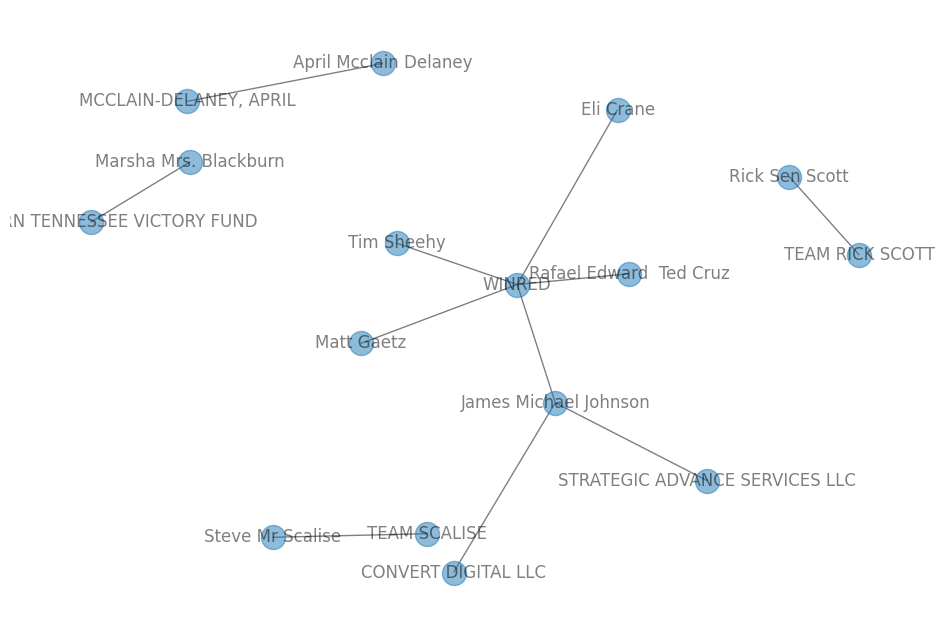

In [893]:
import  matplotlib.pyplot as plt
plt.figure(figsize=(12,8))

pos = nx.spring_layout(B_threshold, seed=15, k =300.0)
nx.draw_networkx(B_threshold, pos, alpha=0.5)

plt.axis('off')
plt.show()

The graph of the network shows that for 4 of the 5 "islands" they only consist of a candidate and their committee. However, one subgroup consists of 5 candidates and 3 committees. In general these candidates would have collected a high amount of donations. When examining all of these races, the majority of them were highly contested. Additionally, both Steve Scalise and James Michael Johnson are in House leadership.

In [894]:
print(f'{len(donor_threshold)} donor nodes')
print(f'{len(candidate_threshold)} candidate nodes')

total_edge_weight = sum(
    B_threshold.edges[n, neighbor].get('weight', 0)
    for n in candidate_threshold
    for neighbor in B_threshold.neighbors(n)
)
print(f"${round(total_edge_weight)} in donations represented in this dataset (this is not all money donated to these candidates, spent by PACs, or spent in other ways during the election).")

7 donor nodes
9 candidate nodes
$547003988 in donations represented in this dataset (this is not all money donated to these candidates, spent by PACs, or spent in other ways during the election).


In [895]:
def sorted_map(d):
    return sorted(d.items(), key = lambda item: (-item[1],item[0]))

### Mid-threshold analysis

The following code prepares centrality analysis for a mid-threshold point between the full network and the nealry $20,000,000 weighted threshold of the previous analysis. The network still contains the majority of nodes.

In [896]:
mid_threshold = 10000

In [897]:
B_mid = B.__class__()
B_mid.add_nodes_from(B.nodes(data=True))

for u, v, d in B.edges(data=True):
    if d.get('weight',0) >= mid_threshold:
        B_mid.add_edge(u, v, **d)

B_mid.remove_nodes_from(list(nx.isolates(B_mid)))

In [898]:
components = [B_mid.subgraph(c).copy() for c in nx.connected_components(B_mid)]
print(f'Number of islands: {len(components)}')

Number of islands: 4


In [899]:
len(B_mid.nodes)

2908

In [900]:
candidate_mid = {n for n, d in bi.color(B_threshold).items() if d == 0}
donor_mid = set(B_threshold) - candidate_threshold

### Centrality Measures

#### Candidates

In [901]:
Cand_proj_mid = bi.projected_graph(B_mid, candidate_mid)
Don_proj_mid = bi.projected_graph(B_mid, donor_mid)

In [902]:
print(sorted(Cand_proj_mid.degree(), key = lambda item: (-item[1], item[0]))[:15])
d = dict(Cand_proj_mid.degree())


[('April Mcclain Delaney', 253), ('James Michael Johnson', 174), ('Eli Crane', 172), ('Marsha Mrs. Blackburn', 160), ('Steve Mr Scalise', 159), ('Rick Sen Scott', 154), ('Rafael Edward  Ted Cruz', 153), ('Tim Sheehy', 153), ('Matt Gaetz', 152), ('Addison Mcdowell', 9), ('Ann L. Wagner', 9), ('Brandon Gill', 9), ('Brandon Mcdonald Williams', 9), ('Brian Fitzpatrick', 9), ('Bryan George Steil', 9)]


In [903]:
dc = nx.degree_centrality(Cand_proj_mid)
sorted_map(nx.degree_centrality(Cand_proj_mid))[:15]

[('April Mcclain Delaney', 0.6009501187648456),
 ('James Michael Johnson', 0.4133016627078385),
 ('Eli Crane', 0.4085510688836105),
 ('Marsha Mrs. Blackburn', 0.3800475059382423),
 ('Steve Mr Scalise', 0.3776722090261283),
 ('Rick Sen Scott', 0.3657957244655582),
 ('Rafael Edward  Ted Cruz', 0.36342042755344417),
 ('Tim Sheehy', 0.36342042755344417),
 ('Matt Gaetz', 0.3610451306413302),
 ('Addison Mcdowell', 0.02137767220902613),
 ('Ann L. Wagner', 0.02137767220902613),
 ('Brandon Gill', 0.02137767220902613),
 ('Brandon Mcdonald Williams', 0.02137767220902613),
 ('Brian Fitzpatrick', 0.02137767220902613),
 ('Bryan George Steil', 0.02137767220902613)]

In [904]:
c = nx.closeness_centrality(Cand_proj_mid)
sorted_map(nx.closeness_centrality(Cand_proj_mid))[:15]

[('April Mcclain Delaney', 0.562082777036048),
 ('Addison Mcdowell', 0.5054021608643458),
 ('Ann L. Wagner', 0.5054021608643458),
 ('Brandon Gill', 0.5054021608643458),
 ('Brandon Mcdonald Williams', 0.5054021608643458),
 ('Brian Fitzpatrick', 0.5054021608643458),
 ('Bryan George Steil', 0.5054021608643458),
 ('Byron Donalds', 0.5054021608643458),
 ('Charles J Fleischmann', 0.5054021608643458),
 ('David P. Joyce', 0.5054021608643458),
 ('David Rouzer', 0.5054021608643458),
 ('David Taylor', 0.5054021608643458),
 ('Eric Burlison', 0.5054021608643458),
 ('Glenn Mr. Thompson', 0.5054021608643458),
 ('H Morgan Griffith', 0.5054021608643458)]

In [905]:
b = nx.betweenness_centrality(Cand_proj_mid)
sorted_map(nx.betweenness_centrality(Cand_proj_mid))[:15]

[('April Mcclain Delaney', 0.7619512624263217),
 ('James Michael Johnson', 0.1347793524407737),
 ('Eli Crane', 0.132593904951388),
 ('Marsha Mrs. Blackburn', 0.07539147564597275),
 ('Steve Mr Scalise', 0.07538742521278885),
 ('Rick Sen Scott', 0.05328875509991861),
 ('Tim Sheehy', 0.05210106709512889),
 ('Rafael Edward  Ted Cruz', 0.05089985619895601),
 ('Matt Gaetz', 0.04875563975920267),
 ('Addison Mcdowell', 0.014583238101450216),
 ('Ann L. Wagner', 0.014583238101450216),
 ('Brandon Gill', 0.014583238101450216),
 ('Brandon Mcdonald Williams', 0.014583238101450216),
 ('Brian Fitzpatrick', 0.014583238101450216),
 ('Bryan George Steil', 0.014583238101450216)]

In [906]:
e = nx.eigenvector_centrality(Cand_proj_mid)
sorted_map(nx.eigenvector_centrality(Cand_proj_mid))[:15]

[('James Michael Johnson', 0.26485174127774613),
 ('Eli Crane', 0.2640646918753219),
 ('Marsha Mrs. Blackburn', 0.26208173178486727),
 ('Steve Mr Scalise', 0.26166317171370407),
 ('Rick Sen Scott', 0.2607419980953215),
 ('Rafael Edward  Ted Cruz', 0.2603899425241983),
 ('Tim Sheehy', 0.26024364585470233),
 ('Matt Gaetz', 0.26003461546561335),
 ('Addison Mcdowell', 0.05646503953195608),
 ('Ann L. Wagner', 0.05646503953195608),
 ('Brandon Gill', 0.05646503953195608),
 ('Brandon Mcdonald Williams', 0.05646503953195608),
 ('Brian Fitzpatrick', 0.05646503953195608),
 ('Bryan George Steil', 0.05646503953195608),
 ('Byron Donalds', 0.05646503953195608)]

In [907]:
candidate_comparison = pd.DataFrame({
    'name': list(Cand_proj_mid.nodes),
    'degree': [d[n] for n in Cand_proj_mid.nodes()],
    'degree_centrality': [dc[n] for n in Cand_proj_mid.nodes()],
    'closeness_centrality': [c[n] for n in Cand_proj_mid.nodes()],
    'betweenness': [b[n] for n in Cand_proj_mid.nodes()],
    'eigenvector': [e[n] for n in Cand_proj_mid.nodes()]
})

In [908]:
candidates.dtypes

name             str
office           str
party            str
state            str
district       int64
donation     float64
node_type        str
dtype: object

In [909]:
candidate_comparison.dtypes

name                        str
degree                    int64
degree_centrality       float64
closeness_centrality    float64
betweenness             float64
eigenvector             float64
dtype: object

In [910]:
candidates['name'] = candidates['name'].str.strip()
candidate_comparison['name'] = candidate_comparison['name'].str.strip()

In [911]:
candidate_comp = pd.merge(candidate_comparison, candidates, on='name', how='left')
candidate_comp.sort_values('degree', ascending = False)[:15]

,name,degree,degree_centrality,closeness_centrality,betweenness,eigenvector,office,party,state,district,donation,node_type
4,April Mcclain Delaney,253,0.600950,0.562083,0.761951,0.048744,H,DEM,MD,6,2.660850e+07,candidate
8,James Michael Johnson,174,0.413302,0.477324,0.134779,0.264852,H,REP,LA,4,1.637087e+08,candidate
7,Eli Crane,172,0.408551,0.476244,0.132594,0.264065,H,REP,AZ,2,2.847565e+07,candidate
0,Marsha Mrs. Blackburn,160,0.380048,0.469866,0.075391,0.262082,S,REP,TN,0,5.638311e+07,candidate
5,Steve Mr Scalise,159,0.377672,0.469342,0.075387,0.261663,H,REP,LA,1,4.418115e+07,candidate
6,Rick Sen Scott,154,0.365796,0.466741,0.053289,0.260742,S,REP,FL,0,4.838129e+07,candidate
1,Rafael Edward Ted Cruz,153,0.363420,0.466224,0.050900,0.260390,S,REP,TX,0,1.045700e+08,candidate
3,Tim Sheehy,153,0.363420,0.466224,0.052101,0.260244,S,REP,MT,0,7.094617e+07,candidate
2,Matt Gaetz,152,0.361045,0.465708,0.048756,0.260035,H,REP,FL,1,5.496840e+07,candidate
53,Harriet Hageman,9,0.021378,0.505402,0.014583,0.056465,H,REP,WY,0,2.859055e+06,candidate


When considering the centrality factors above, and comparing them with the analysis of the full network, there are some stark contrasts.

This more limited network has nine candidates with relatively high degrees of centrality and closeness but varying degrees of betweenness and eigenvector centrality. These are almost all candidates connected to the major Republican committee WinRed. The other candidates have much lower degree centrality but higher betweenness, indicating they are likely part of a separate subgroup around a central donor committee. Interestingly, almost all candidates in the list, except one, are now Republican. This is very different from the fully Democrat list from the full network. This likely indicates that democrats are getting lower dollar donations from more committees.

### Centrality Measures

#### Donors

The following code analyzes the centrality of the donors of the mid-network.

In [912]:
print(sorted(Don_proj_mid.degree(), key=lambda item: (-item[1], item[0]))[:15])
Don_d = dict(Don_proj_mid.degree())

[('WINRED', 925), ('BLACKBURN TENNESSEE VICTORY FUND', 9), ('CONVERT DIGITAL LLC', 9), ('MCCLAIN-DELANEY, APRIL', 9), ('STRATEGIC ADVANCE SERVICES LLC', 9), ('TEAM RICK SCOTT', 9), ('TEAM SCALISE', 9), ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC', 3), ('ANONYMOUS, ANONYMOUS', 3), ('CORNYN VICTORY COMMITTEE', 3), ('GROW THE MAJORITY', 3), ('HUCKPAC', 3), ('HUSCH BLACKWELL POLITICAL ACTION COMMITTEE', 3), ('JOHNSON LEADERSHIP FUND', 3), ('LEVY, EDWARD C. MR.', 3)]


In [913]:
Don_dc = nx.degree_centrality(Don_proj_mid)
sorted_map(nx.degree_centrality(Don_proj_mid))[:15]

[('WINRED', 0.9924892703862661),
 ('BLACKBURN TENNESSEE VICTORY FUND', 0.009656652360515022),
 ('CONVERT DIGITAL LLC', 0.009656652360515022),
 ('MCCLAIN-DELANEY, APRIL', 0.009656652360515022),
 ('STRATEGIC ADVANCE SERVICES LLC', 0.009656652360515022),
 ('TEAM RICK SCOTT', 0.009656652360515022),
 ('TEAM SCALISE', 0.009656652360515022),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC', 0.003218884120171674),
 ('ANONYMOUS, ANONYMOUS', 0.003218884120171674),
 ('CORNYN VICTORY COMMITTEE', 0.003218884120171674),
 ('GROW THE MAJORITY', 0.003218884120171674),
 ('HUCKPAC', 0.003218884120171674),
 ('HUSCH BLACKWELL POLITICAL ACTION COMMITTEE', 0.003218884120171674),
 ('JOHNSON LEADERSHIP FUND', 0.003218884120171674),
 ('LEVY, EDWARD C. MR.', 0.003218884120171674)]

In [918]:
Don_c = nx.closeness_centrality(Don_proj_mid)
sorted_map(nx.closeness_centrality(Don_proj_mid))[:15]

[('WINRED', 0.9862433862433863),
 ("AMERICA'S CREDIT UNIONS PAC OF CREDIT UNION NATIONAL ASSOCIATION, INC.",
  0.5005370569280344),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLITICAL ACTION COMMITTEE',
  0.5005370569280344),
 ('CARPENTERS LEGISLATIVE IMPROVEMENT COMMITTEE UNITED BROTHERHOOD OF CARPENTERS AND JOINERS',
  0.5005370569280344),
 ('BLACKBURN TENNESSEE VICTORY FUND', 0.4989293361884368),
 ('CONVERT DIGITAL LLC', 0.4989293361884368),
 ('STRATEGIC ADVANCE SERVICES LLC', 0.4989293361884368),
 ('TEAM RICK SCOTT', 0.4989293361884368),
 ('TEAM SCALISE', 0.4989293361884368),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC', 0.4973319103521878),
 ('ANONYMOUS, ANONYMOUS', 0.4973319103521878),
 ('CORNYN VICTORY COMMITTEE', 0.4973319103521878),
 ('GROW THE MAJORITY', 0.4973319103521878),
 ('HUCKPAC', 0.4973319103521878),
 ('HUSCH BLACKWELL POLITICAL ACTION COMMITTEE', 0.4973319103521878)]

In [914]:
Don_b = nx.betweenness_centrality(Don_proj_mid)
sorted_map(nx.betweenness_centrality(Don_proj_mid))[:15]

[('WINRED', 0.9996796098154646),
 ('MCCLAIN-DELANEY, APRIL', 0.012844419448375692),
 ("AMERICA'S CREDIT UNIONS PAC OF CREDIT UNION NATIONAL ASSOCIATION, INC.",
  0.004964127055837018),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLITICAL ACTION COMMITTEE',
  0.004964127055837018),
 ('CARPENTERS LEGISLATIVE IMPROVEMENT COMMITTEE UNITED BROTHERHOOD OF CARPENTERS AND JOINERS',
  0.004964127055837018),
 ('BLACKBURN TENNESSEE VICTORY FUND', 3.226951498918971e-05),
 ('TEAM RICK SCOTT', 3.226951498918971e-05),
 ('TEAM SCALISE', 3.226951498918971e-05),
 ('CONVERT DIGITAL LLC', 1.6134757494594856e-05),
 ('STRATEGIC ADVANCE SERVICES LLC', 1.6134757494594856e-05),
 ('CORNYN VICTORY COMMITTEE', 1.152482678185347e-06),
 (' KRISTI PAC', 0.0),
 ('2024 REPUBLICAN SENATE VICTORY', 0.0),
 ('2024 THUNE REPUBLICAN SENATE VICTORY', 0.0),
 ('31 DAYS PAC', 0.0)]

In [925]:
Don_e = nx.eigenvector_centrality(Don_proj_mid, max_iter = 1000)
sorted_map(nx.eigenvector_centrality(Don_proj_mid, max_iter = 1000))[:15]

[('WINRED', 0.7064518298064697),
 ('CONVERT DIGITAL LLC', 0.029953229762653855),
 ('STRATEGIC ADVANCE SERVICES LLC', 0.029953229762653855),
 ('BLACKBURN TENNESSEE VICTORY FUND', 0.029566064455894894),
 ('TEAM RICK SCOTT', 0.029566064455894894),
 ('TEAM SCALISE', 0.029533927934174475),
 ('AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC', 0.025155877131536625),
 ('ANONYMOUS, ANONYMOUS', 0.025155877131536625),
 ('GROW THE MAJORITY', 0.025155877131536625),
 ('HUCKPAC', 0.025155877131536625),
 ('HUSCH BLACKWELL POLITICAL ACTION COMMITTEE', 0.025155877131536625),
 ('JOHNSON LEADERSHIP FUND', 0.025155877131536625),
 ('LEVY, EDWARD C. MR.', 0.025155877131536625),
 ('CORNYN VICTORY COMMITTEE', 0.025130457941998596),
 ('BOWE, PETER A. MR.', 0.0241598894044525)]

In [926]:
donor_comparison = pd.DataFrame({
    'name': list(Don_proj_mid.nodes),
    'degree': [Don_d[n] for n in Don_proj_mid.nodes()],
    'closeness': [Don_c[n] for n in Don_proj_mid.nodes()],
    'degree_centrality': [Don_dc[n] for n in Don_proj_mid.nodes()],
    'betweenness': [Don_b[n] for n in Don_proj_mid.nodes()],
    'eigenvector': [Don_e[n] for n in Don_proj_mid.nodes()]
})

In [927]:
donor_comparison.sort_values('degree', ascending=False)[:15]

,name,degree,closeness,degree_centrality,betweenness,eigenvector
0,WINRED,925,0.986243,0.992489,0.999680,0.706452
1,TEAM SCALISE,9,0.498929,0.009657,0.000032,0.029534
2,CONVERT DIGITAL LLC,9,0.498929,0.009657,0.000016,0.029953
3,BLACKBURN TENNESSEE VICTORY FUND,9,0.498929,0.009657,0.000032,0.029566
4,TEAM RICK SCOTT,9,0.498929,0.009657,0.000032,0.029566
5,"MCCLAIN-DELANEY, APRIL",9,0.335614,0.009657,0.012844,0.002306
6,STRATEGIC ADVANCE SERVICES LLC,9,0.498929,0.009657,0.000016,0.029953
855,GROW THE MAJORITY,3,0.497332,0.003219,0.000000,0.025156
849,"LEVY, EDWARD C. MR.",3,0.497332,0.003219,0.000000,0.025156
458,HUCKPAC,3,0.497332,0.003219,0.000000,0.025156


This donor network at this 1000 level weighted edge indicates that the vast majority of existing connections are to WinRed as it is fundamentally central, outpacing degree centrality of all other committees by at least 10 times the other committees. There is potential that this indicates that Repbulican candidates are getting their funding from a smaller number of high dollar donations and committees. Which raises questions about when a candidate has bigger donations from fewer people, do they answer to the people? Or to their donors?